In [1]:
import os
os.chdir('..')
print(os.getcwd())
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

from datasets.imagewoof_dataset import ImageWoofDataset

ds_woof = ImageWoofDataset('val')

/home/keuth/storage/staff/ronkeuth/FlexConv


loading val dataset: 100%|██████████| 3929/3929 [01:29<00:00, 43.69img/s]


In [2]:
from random import randint
import torch

batch = torch.stack([ds_woof[randint(0, len(ds_woof)-1)][0] for _ in range(8)])

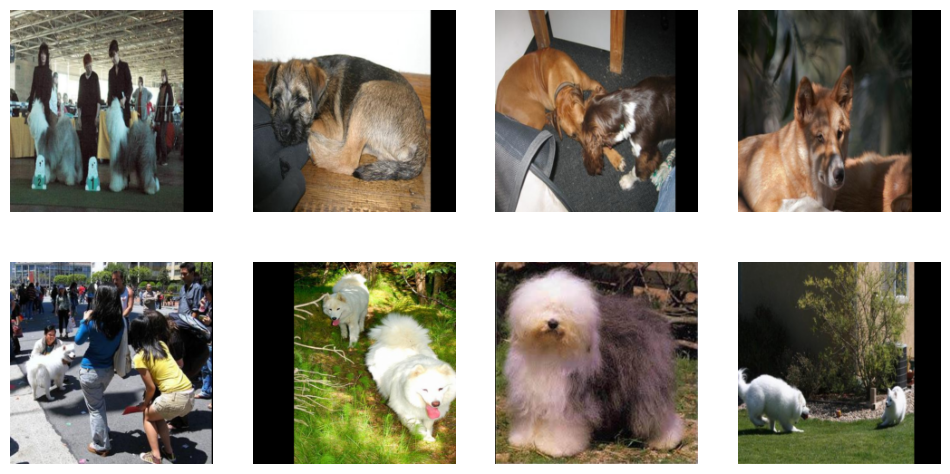

In [3]:
from matplotlib import pyplot as plt

def plot_imgs(batch):
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(8):
        axs[i//4, i%4].imshow(batch[i].permute(1, 2, 0))
        axs[i//4, i%4].axis('off')
    plt.show()

plot_imgs(batch)

In [5]:
from kornia.augmentation import auto

kornia_aug = auto.AutoAugment()
plot_imgs(kornia_aug(batch))

NameError: name 'plot_imgs' is not defined

In [6]:
from torchvision import transforms

torchvision_aug = transforms.AutoAugment()
plot_imgs(torchvision_aug(batch.mul(255).byte()))

NameError: name 'plot_imgs' is not defined

# Benchmarking

In [3]:
batch_float = torch.stack([ds_woof[randint(0, len(ds_woof)-1)][0] for _ in range(128)]).cuda()
batch_byte = batch_float.mul(255).byte().cuda()

In [12]:
%timeit -n 30 kornia_aug(batch_float)

113 ms ± 10.5 ms per loop (mean ± std. dev. of 7 runs, 30 loops each)


In [13]:
%timeit -n 30 torchvision_aug(batch_byte)

21.6 ms ± 5.24 ms per loop (mean ± std. dev. of 7 runs, 30 loops each)
